Tugas 1A Pemrograman Bahasa Alami - Metta Anjali Putri - 5026231205

1. INSTALL & IMPORT

In [1]:
!pip install google-play-scraper pandas nltk scikit-learn matplotlib seaborn wordcloud textblob

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from google_play_scraper import reviews, Sort

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from wordcloud import WordCloud
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

2. SCRAPING DATA

In [2]:
print("Scraping data BookCabin...")

result, _ = reviews(
    'com.kabinkitatop.bookcabin',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=20000
)

df = pd.DataFrame(result)

# Ambil kolom penting
df = df[['content', 'score']]

# Hapus duplikat
df.drop_duplicates(subset='content', inplace=True)

print("Total data:", len(df))

# Simpan raw data
df.to_csv("bookcabin_raw.csv", index=False)

Scraping data BookCabin...
Total data: 3245


3. PREPROCESSING

In [3]:
import nltk
from nltk.corpus import stopwords

!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# stopwords indonesia
stop_words = set(stopwords.words('indonesian'))

# stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    text = [stemmer.stem(word) for word in text]
    return ' '.join(text)

df['clean_text'] = df['content'].apply(clean_text)

df.head()

,content,score,clean_text
0,"Kenapa refundnya susah bngt sih,, dsuruh nungg...",1,refundnya susah bngt sih dsuruh nunggu bulan g...
1,sangat membantu,4,bantu
2,saya senang menggunakan aplikasi BookCabin ama...,5,senang aplikasi bookcabin aman cepat percaya
3,tempat beli tiket paling murah dibandingkan yg...,5,beli tiket murah banding yg
4,semakin jays,5,jays


4. LABELING SENTIMENT

In [4]:
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['sentiment'] = df['score'].apply(label_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
positif,2429
negatif,740
netral,76


5. WorldCloud

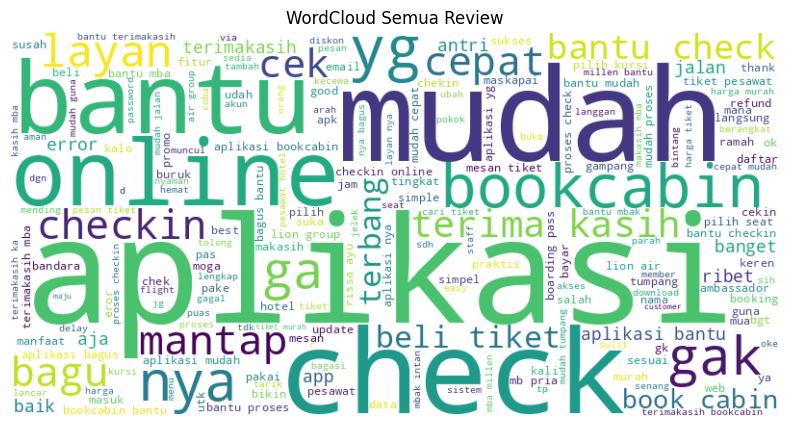

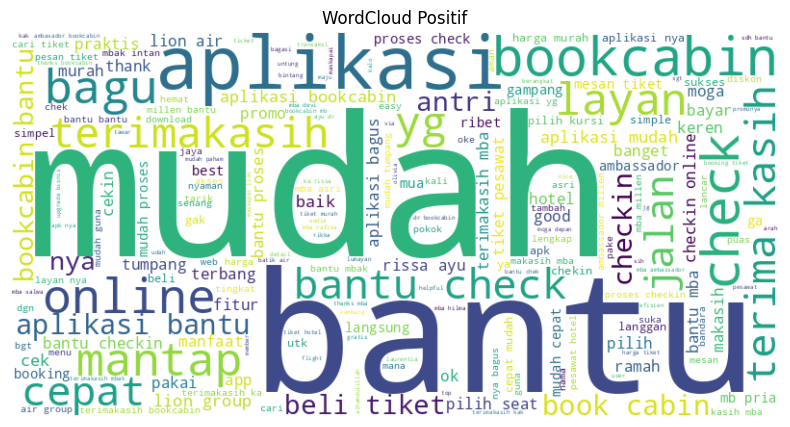

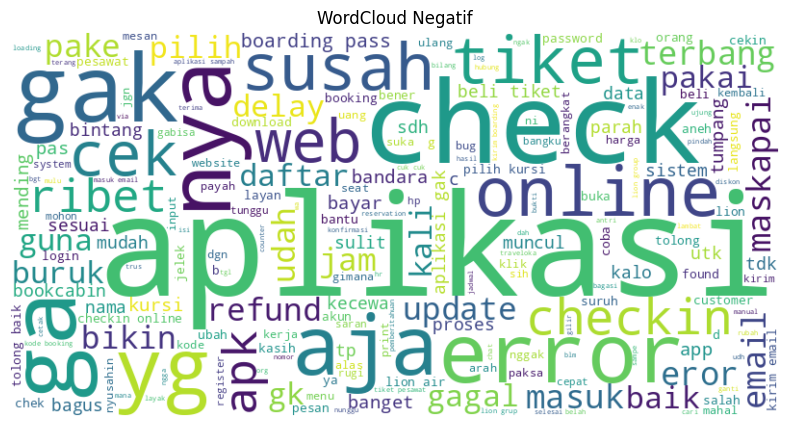

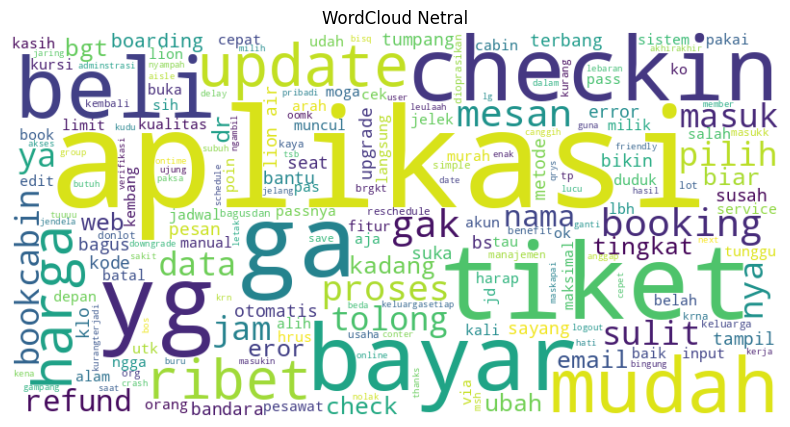

In [5]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = ' '.join(df['clean_text'])

wc_all = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Semua Review")
plt.show()

text_pos = ' '.join(df[df['sentiment']=='positif']['clean_text'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Positif")
plt.show()

text_neg = ' '.join(df[df['sentiment']=='negatif']['clean_text'])

wc_neg = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Negatif")
plt.show()

text_net = ' '.join(df[df['sentiment']=='netral']['clean_text'])

wc_net = WordCloud(width=800, height=400, background_color='white').generate(text_net)

plt.figure(figsize=(10,5))
plt.imshow(wc_net, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Netral")
plt.show()

6. SPLIT DATA

In [6]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

7. TF-IDF VECTORIZATION

In [7]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

8. TRAIN MODEL

In [8]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     negatif       0.89      0.61      0.73       139
      netral       0.00      0.00      0.00        13
     positif       0.89      0.99      0.94       497

    accuracy                           0.89       649
   macro avg       0.59      0.53      0.55       649
weighted avg       0.87      0.89      0.87       649



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


9. Final Output

In [9]:
df['predicted_sentiment'] = model.predict(tfidf.transform(df['clean_text']))

# Simpan ke CSV
df.to_csv("bookcabin_sentiment_analysis.csv", index=False)

print("File berhasil disimpan sebagai bookcabin_sentiment_analysis.csv")

sentiment_counts = df['predicted_sentiment'].value_counts()

total = len(df)
positif = sentiment_counts.get('positif', 0)
negatif = sentiment_counts.get('negatif', 0)
netral = sentiment_counts.get('netral', 0)

pos_pct = (positif / total) * 100
neg_pct = (negatif / total) * 100
net_pct = (netral / total) * 100

print("\n===== HASIL ANALISIS SENTIMEN =====")
print(f"Total data: {total}")
print(f"Positif : {positif} ({pos_pct:.2f}%)")
print(f"Negatif : {negatif} ({neg_pct:.2f}%)")
print(f"Netral  : {netral} ({net_pct:.2f}%)")

if pos_pct > neg_pct:
    print("\nMayoritas pengguna memberikan sentimen POSITIF terhadap aplikasi BookCabin.")
else:
    print("\nMayoritas pengguna memberikan sentimen NEGATIF terhadap aplikasi BookCabin.")

print("Hasil ini dapat digunakan sebagai evaluasi untuk meningkatkan kualitas layanan dan pengalaman pengguna.")

File berhasil disimpan sebagai bookcabin_sentiment_analysis.csv

===== HASIL ANALISIS SENTIMEN =====
Total data: 3245
Positif : 2650 (81.66%)
Negatif : 595 (18.34%)
Netral  : 0 (0.00%)

Mayoritas pengguna memberikan sentimen POSITIF terhadap aplikasi BookCabin.
Hasil ini dapat digunakan sebagai evaluasi untuk meningkatkan kualitas layanan dan pengalaman pengguna.
